# Exploring the CQI Coffee Quality Dataset

Initial exploration of farm data, cupping scores, and processing methods.

**Setup:** Download the dataset from [Kaggle](https://www.kaggle.com/datasets/fatihb/coffee-quality-data-cqi) and place it in `data/raw/`.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.data import load_cqi

sns.set_theme(style="whitegrid")

df = load_cqi()
df.head()

,unnamed:_0,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,...,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,2,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,3,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,4,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,5,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


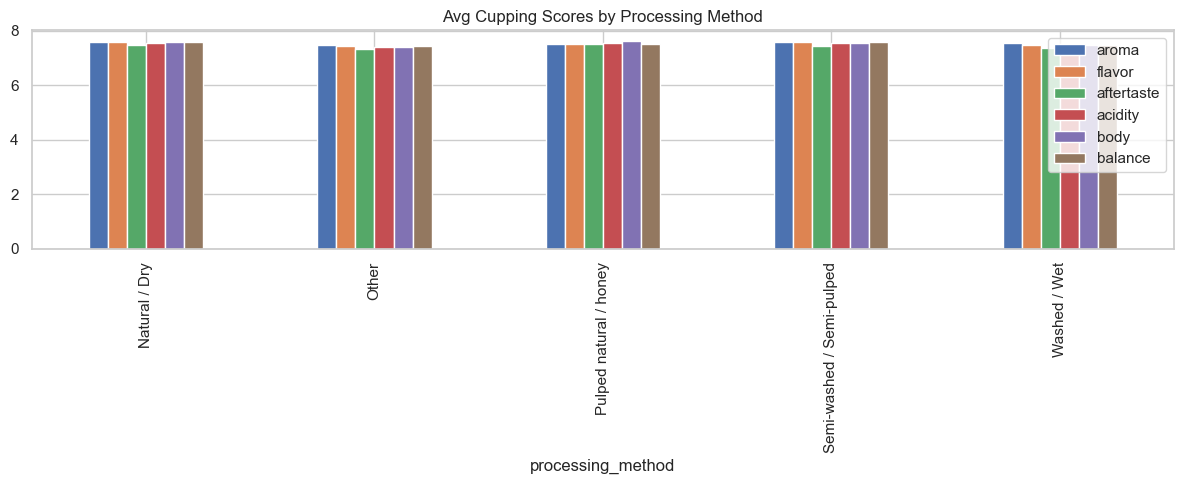

In [2]:
# Processing methods vs cupping scores
cupping_cols = ["aroma", "flavor", "aftertaste", "acidity", "body", "balance"]
existing = [c for c in cupping_cols if c in df.columns]

if "processing_method" in df.columns:
    method_scores = df.groupby("processing_method")[existing].mean()
    method_scores.plot(kind="bar", figsize=(12, 5), title="Avg Cupping Scores by Processing Method")
    plt.tight_layout()
    plt.show()

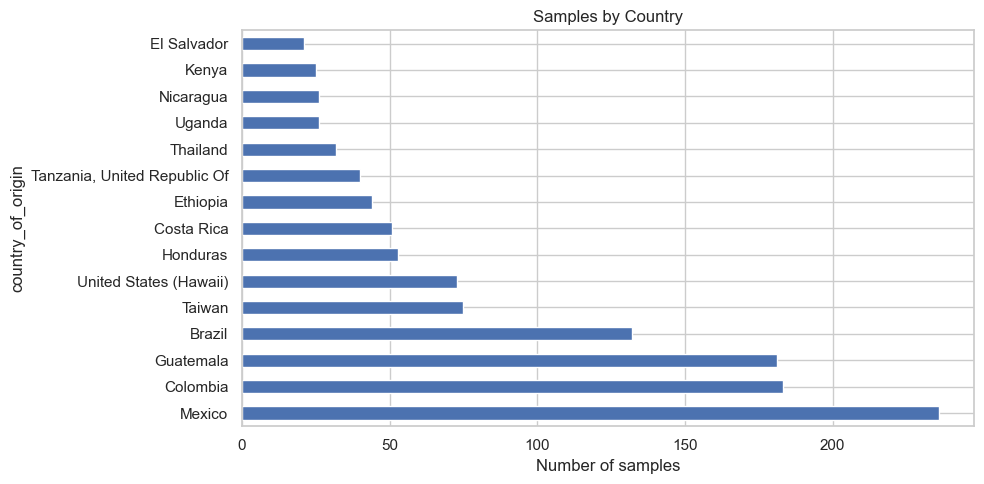

In [3]:
# Top producing countries by sample count
if "country_of_origin" in df.columns:
    df["country_of_origin"].value_counts().head(15).plot(
        kind="barh", figsize=(10, 5), title="Samples by Country"
    )
    plt.xlabel("Number of samples")
    plt.tight_layout()
    plt.show()

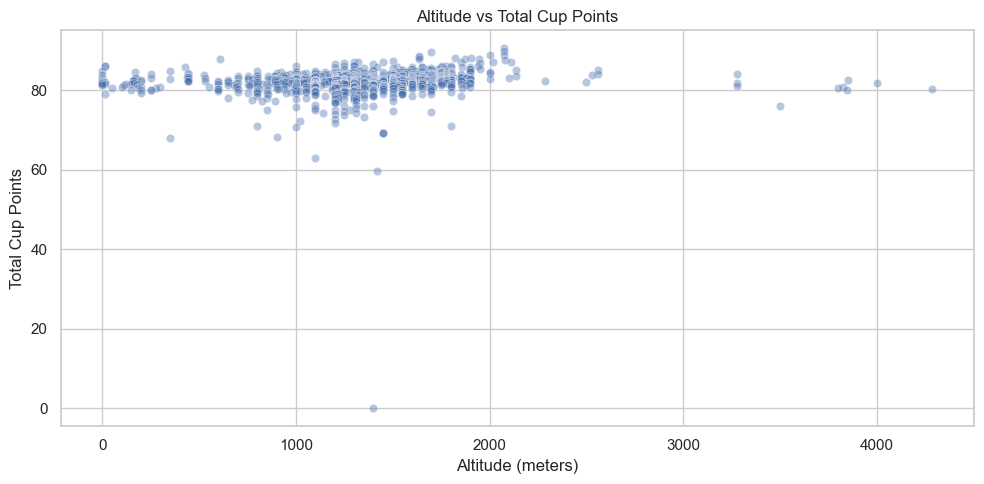

In [4]:
# Altitude vs total cupping score
clean = df.dropna(subset=["altitude_mean_meters", "total_cup_points"])
clean = clean[clean["altitude_mean_meters"] < 5000]  # filter outliers

plt.figure(figsize=(10, 5))
sns.scatterplot(data=clean, x="altitude_mean_meters", y="total_cup_points", alpha=0.4)
plt.title("Altitude vs Total Cup Points")
plt.xlabel("Altitude (meters)")
plt.ylabel("Total Cup Points")
plt.tight_layout()
plt.show()